In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import joblib
import json
import time
import os
import wandb
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import userdata
wandb_api_key = userdata.get('WANDB_API_KEY_1')
wandb.login(key=wandb_api_key)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: akeke23 (akeke23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
import numpy as np
import json


BASE = '/content/drive/MyDrive/Ketastasia/data'


data = np.load(f'{BASE}/dataset_seq_33kp_ready.npz')
X_test, y_test, y_test_idx = data['X_test'], data['y_test'], data['y_test_int']


with open(f'{BASE}/pipeline2A_metadata.json') as f:
    meta = json.load(f)


classes = meta['classes']
print(f"Test set loaded: X_test {X_test.shape}, y_test_idx {y_test_idx.shape}")


Test set loaded: X_test (1100, 15, 72), y_test_idx (1100,)


In [5]:
run = wandb.init(project="ildolcefarniente", group="p2_gru", job_type="download")
artifact = run.use_artifact('best_p2_gru_pipeline:latest')
artifact_dir = artifact.download()
run.finish()


import joblib
p2_gru_pipeline = joblib.load(f"{artifact_dir}/p2_gru_pipeline.pkl")
y_pred_test = p2_gru_pipeline.predict(X_test)


wandb:   1 of 1 files downloaded.  


-> Loading Keras model from: /content/drive/MyDrive/Ketastasia/data/models/gru_lr_0.001_d0.3.keras


In [6]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


test_acc = accuracy_score(y_test_idx, y_pred_test)
test_f1_macro = f1_score(y_test_idx, y_pred_test, average='macro', zero_division=0)
test_f1_weighted = f1_score(y_test_idx, y_pred_test, average='weighted', zero_division=0)


print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Macro: {test_f1_macro:.4f}")
print(f"Test F1 Weighted: {test_f1_weighted:.4f}")


report_test = classification_report(
    y_test_idx, y_pred_test,
    labels=list(range(len(classes))),
    target_names=classes,
    zero_division=0
)
print("\n=== Per-class report (Test set) ===")
print(report_test)


Test Accuracy: 0.7782
Test F1 Macro: 0.7269
Test F1 Weighted: 0.7764

=== Per-class report (Test set) ===
                     precision    recall  f1-score   support

        bench_press       0.75      0.66      0.70        77
         bicep_curl       0.57      0.65      0.60        20
          chest_fly       0.90      0.64      0.75        14
     clean_and_jerk       0.87      0.82      0.85       136
           deadlift       0.58      0.61      0.59        18
decline_bench_press       0.96      0.61      0.75        36
        hammer_curl       0.67      0.69      0.68        26
         hip_thrust       0.83      0.64      0.72        59
incline_bench_press       0.36      0.56      0.43         9
          jump_rope       1.00      0.22      0.36         9
      jumping_jacks       0.00      0.00      0.00         0
       lat_pulldown       1.00      0.84      0.91        19
      lateral_raise       0.75      0.91      0.82        45
      leg_extension       0.88      1.0

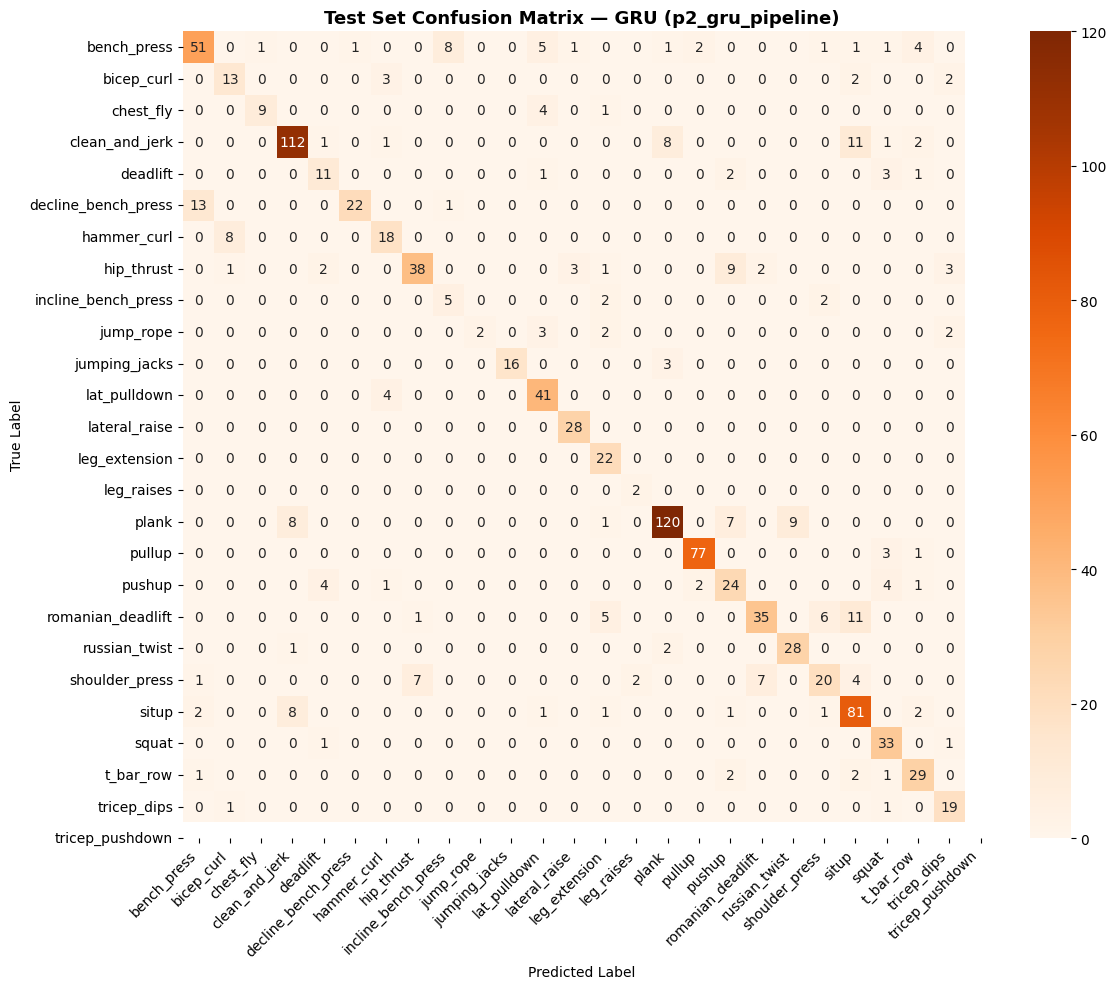

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


cm_test = confusion_matrix(y_test_idx, y_pred_test)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title('Test Set Confusion Matrix — GRU (p2_gru_pipeline)', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{BASE}/models/gru_test_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
import wandb


run = wandb.init(
    project="ildolcefarniente",
    group="p2_gru",
    name="gru_final_test_evaluation"
)


wandb.log({
    "final_test_accuracy": test_acc,
    "final_test_f1_macro": test_f1_macro,
    "final_test_f1_weighted": test_f1_weighted,
    "test_confusion_matrix_img": wandb.Image(f'{BASE}/models/gru_test_confusion_matrix.png')
})


wandb.finish()
print("Test results logged to WandB")


final_test_accuracy,▁
final_test_f1_macro,▁
final_test_f1_weighted,▁
final_test_accuracy,0.77818
final_test_f1_macro,0.72692
final_test_f1_weighted,0.77644


Test results logged to WandB
